In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
# Step 3: Load dataset
df = pd.read_csv("Dark Side of Social Media.csv")
print("Shape:", df.shape)
df.head()


Shape: (1000, 31)


,UserID,Age,Gender,Location,Income,Debt,Owns Property,Profession,Demographics,Platform,...,ProductivityLoss,Satisfaction,Watch Reason,DeviceType,OS,Watch Time,Self Control,Addiction Level,CurrentActivity,ConnectionType
0,1,56,Male,Pakistan,82812,True,True,Engineer,Rural,Instagram,...,3,7,Procrastination,Smartphone,Android,9:00 PM,5,5,Commuting,Mobile Data
1,2,46,Female,Mexico,27999,False,True,Artist,Urban,Instagram,...,5,5,Habit,Computer,Android,5:00 PM,7,3,At school,Wi-Fi
2,3,32,Female,United States,42436,False,True,Engineer,Rural,Facebook,...,6,4,Entertainment,Tablet,Android,2:00 PM,8,2,At home,Mobile Data
3,4,60,Male,Barzil,62963,True,False,Waiting staff,Rural,YouTube,...,3,7,Habit,Smartphone,Android,9:00 PM,5,5,Commuting,Mobile Data
4,5,25,Male,Pakistan,22096,False,True,Manager,Urban,TikTok,...,8,2,Boredom,Smartphone,iOS,8:00 AM,10,0,At home,Mobile Data


In [4]:
# Step 4: Preprocess

import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# --- 1. Select features and target ---
features = ["Total Time Spent", "Self Control", "Addiction Level", "CurrentActivity"]
target = "ProductivityLoss"

# --- 2. Handle categorical variable ---
le = LabelEncoder()
df = df.copy()  # make sure we're working with a copy of the original dataframe
df["CurrentActivity_enc"] = le.fit_transform(df["CurrentActivity"])

# --- 3. Create target classes (Low, Medium, High) if not already ---
df["ProdClass"] = pd.qcut(df[target], q=3, labels=["Low", "Medium", "High"])

# --- 4. Prepare X and y ---
X = df[["Total Time Spent", "Self Control", "Addiction Level", "CurrentActivity_enc"]].copy()
y = df["ProdClass"]

# --- 5. Scale numeric features ---
scaler = StandardScaler()
numeric_features = ["Total Time Spent", "Self Control", "Addiction Level"]
X[numeric_features] = scaler.fit_transform(X[numeric_features])

# --- 6. Ready for model training ---
print("Preprocessing completed. Feature matrix X shape:", X.shape)
print("Target vector y shape:", y.shape)


Preprocessing completed. Feature matrix X shape: (1000, 4)
Target vector y shape: (1000,)


In [12]:
df = df.copy()

# Encode categorical variable
le = LabelEncoder()
df["CurrentActivity_enc"] = le.fit_transform(df["CurrentActivity"])

# Create target classes (Low, Medium, High)
df["ProdClass"] = pd.qcut(df["ProductivityLoss"], q=3, labels=["Low", "Medium", "High"])

# Prepare feature matrix X and target y
X = df[["Total Time Spent", "Self Control", "Addiction Level", "CurrentActivity_enc"]].copy()
y = df["ProdClass"]

# Scale numeric features
scaler = StandardScaler()
numeric_cols = ["Total Time Spent", "Self Control", "Addiction Level"]
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [13]:
# Step 6: Train model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Test Accuracy: 0.995
              precision    recall  f1-score   support

        High       1.00      0.98      0.99        48
         Low       1.00      1.00      1.00        71
      Medium       0.99      1.00      0.99        81

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200



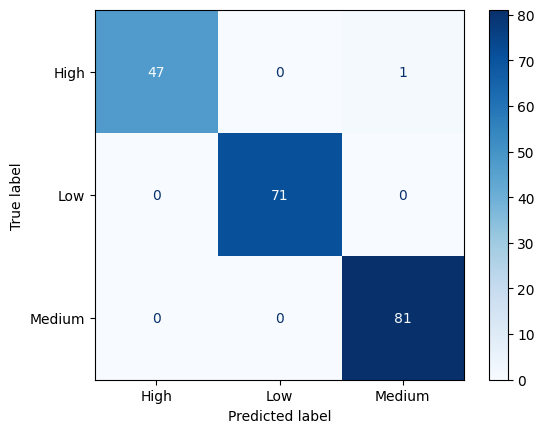

In [14]:
y_pred = rf.predict(X_test)

# Accuracy
print("Test Accuracy:", accuracy_score(y_test, y_pred))

# Classification report
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap="Blues")
plt.show()


In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring="accuracy")
print("Cross-validation accuracies:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())


Cross-validation accuracies: [0.995 0.99  1.    1.    1.   ]
Mean CV accuracy: 0.9969999999999999


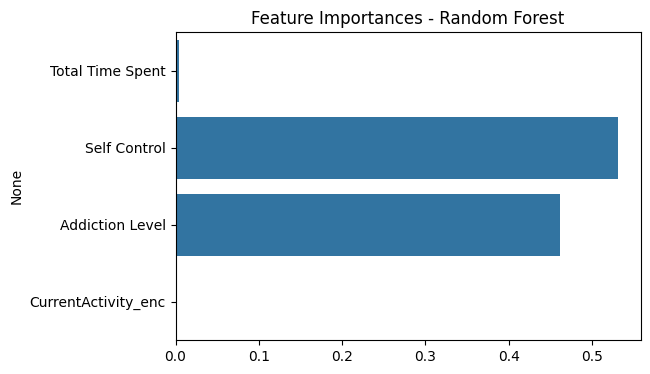

In [16]:
importances = rf.feature_importances_
features_list = X.columns

plt.figure(figsize=(6,4))
sns.barplot(x=importances, y=features_list)
plt.title("Feature Importances - Random Forest")
plt.show()


In [17]:
def predict_productivity(new_user, rf_model, le_encoder, scaler_obj):
    """
    Predict productivity class for a new user.
    
    new_user: dict with keys "Total Time Spent", "Self Control", "Addiction Level", "CurrentActivity"
    rf_model: trained RandomForestClassifier
    le_encoder: fitted LabelEncoder for CurrentActivity
    scaler_obj: fitted StandardScaler for numeric features
    """
    
    # Encode activity safely
    activity = new_user["CurrentActivity"]
    if activity in le_encoder.classes_:
        activity_enc = le_encoder.transform([activity])[0]
    else:
        print(f"Warning: '{activity}' is unseen. Assigning default encoding 0.")
        activity_enc = 0  # fallback encoding
    
    # Prepare DataFrame
    df_new = pd.DataFrame([[
        new_user["Total Time Spent"],
        new_user["Self Control"],
        new_user["Addiction Level"],
        activity_enc
    ]], columns=["Total Time Spent", "Self Control", "Addiction Level", "CurrentActivity_enc"])
    
    # Scale numeric features
    numeric_cols = ["Total Time Spent", "Self Control", "Addiction Level"]
    df_new[numeric_cols] = scaler_obj.transform(df_new[numeric_cols])
    
    # Predict
    pred_class = rf_model.predict(df_new)[0]
    
    return pred_class

# Example usage
new_user_data = {
    "Total Time Spent": 5.0,
    "Self Control": 3.5,
    "Addiction Level": 2.0,
    "CurrentActivity": "Social Media"  # could be unseen
}

predicted_class = predict_productivity(new_user_data, rf, le, scaler)
print("Predicted Productivity Class:", predicted_class)

Predicted Productivity Class: Low


In [18]:
new_user_data = {
    "Total Time Spent": 120,   # example numeric value
    "Self Control": 7,         # example numeric value
    "Addiction Level": 3,      # example numeric value
    "CurrentActivity": "At work"  # must be from known_activities
}

# Predict using the function from before
predicted_class = predict_productivity(new_user_data, rf, le, scaler)
print("Predicted Productivity Class:", predicted_class)


Predicted Productivity Class: Medium


In [19]:
import random

# Known activities
known_activities = ["Commuting", "At school", "At home", "At work"]

# Generate 20 new users
new_users = []
for i in range(20):
    user = {
        "Total Time Spent": random.randint(20, 300),       # minutes
        "Self Control": random.randint(1, 10),
        "Addiction Level": random.randint(0, 10),
        "CurrentActivity": random.choice(known_activities)
    }
    new_users.append(user)

# Predict productivity for all 20 users
for idx, user_data in enumerate(new_users, start=1):
    pred_class = predict_productivity(user_data, rf, le, scaler)
    print(f"User {idx}: {user_data} --> Predicted Productivity Class: {pred_class}")


User 1: {'Total Time Spent': 164, 'Self Control': 10, 'Addiction Level': 9, 'CurrentActivity': 'Commuting'} --> Predicted Productivity Class: Low
User 2: {'Total Time Spent': 189, 'Self Control': 8, 'Addiction Level': 1, 'CurrentActivity': 'At home'} --> Predicted Productivity Class: Medium
User 3: {'Total Time Spent': 158, 'Self Control': 10, 'Addiction Level': 9, 'CurrentActivity': 'Commuting'} --> Predicted Productivity Class: Low
User 4: {'Total Time Spent': 39, 'Self Control': 1, 'Addiction Level': 1, 'CurrentActivity': 'At school'} --> Predicted Productivity Class: Low
User 5: {'Total Time Spent': 37, 'Self Control': 7, 'Addiction Level': 3, 'CurrentActivity': 'At work'} --> Predicted Productivity Class: Medium
User 6: {'Total Time Spent': 184, 'Self Control': 10, 'Addiction Level': 8, 'CurrentActivity': 'At home'} --> Predicted Productivity Class: Low
User 7: {'Total Time Spent': 240, 'Self Control': 3, 'Addiction Level': 7, 'CurrentActivity': 'Commuting'} --> Predicted Producti